# 06 - CNN Training

Notebook này dùng để **huấn luyện các mô hình CNN / Transfer Learning** cho bài toán phân loại ảnh cảnh Intel Image Classification.

Mục tiêu chính:

1. Dùng lại split đã tạo từ `02_preprocessing.ipynb`.
2. Train một mô hình **Simple CNN** tự xây dựng.
3. Train một mô hình **ResNet18 Transfer Learning**.
4. Fine-tune ResNet18.
5. Lưu checkpoint, history, metric và prediction để notebook đánh giá sau này sử dụng.

Notebook này được thiết kế để chạy được trên:

- Google Colab
- Máy local

## 1. Import thư viện và cấu hình môi trường

Chỉ cần chỉnh `PROJECT_ROOT` cho đúng thư mục project của bạn.

Cấu trúc project kỳ vọng:

```text
intel_image_project/
├── data/
│   ├── raw/
│   ├── splits/
│   │   ├── train.csv
│   │   ├── val.csv
│   │   └── test.csv
│   └── metadata/
│       └── class_to_idx.json
├── models/
├── outputs/
└── notebooks/
```

In [ ]:
import os
import sys
import json
import time
import copy
import random
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
import subprocess
import shutil



from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Thiết lập `PROJECT_ROOT`

### Khi chạy trên Google Colab

Nếu project của bạn nằm trong Google Drive, mở comment phần `drive.mount`.

Ví dụ:

```python
PROJECT_ROOT = Path("/content/drive/MyDrive/intel_image_project")
```

### Khi chạy local

Nếu notebook nằm trong thư mục `notebooks/`, code sẽ tự suy ra thư mục project là thư mục cha.

In [ ]:
# =========================
# PROJECT ROOT CONFIG - FAST COLAB VERSION
# =========================

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")
    LOCAL_ROOT = Path("/content/intel_image_project")
    ARCHIVE_PATH = DRIVE_ROOT / "data.tar"
    LOCAL_ARCHIVE_PATH = Path("/content/data.tar")

    if not DRIVE_ROOT.exists():
        raise FileNotFoundError(f"Không tìm thấy DRIVE_ROOT: {DRIVE_ROOT}")

    if not ARCHIVE_PATH.exists():
        raise FileNotFoundError(
            f"Không tìm thấy {ARCHIVE_PATH}. "
            "Bạn cần tạo data.tar trước."
        )

    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

    if not (LOCAL_ROOT / "data").exists():
        print("Đang copy data.tar từ Drive sang /content...")
        shutil.copy2(ARCHIVE_PATH, LOCAL_ARCHIVE_PATH)

        print("Đang giải nén data.tar...")
        !tar -xf "/content/data.tar" -C "/content/intel_image_project"

        print("Đã chuẩn bị data local xong.")
    else:
        print("Data local đã tồn tại, bỏ qua bước copy.")

    PROJECT_ROOT = LOCAL_ROOT

else:
    CURRENT_DIR = Path.cwd()

    if CURRENT_DIR.name == "notebooks":
        PROJECT_ROOT = CURRENT_DIR.parent
    else:
        PROJECT_ROOT = CURRENT_DIR

    DRIVE_ROOT = None

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
SPLIT_DIR = DATA_DIR / "splits"
METADATA_DIR = DATA_DIR / "metadata"

MODEL_DIR = PROJECT_ROOT / "models" / "cs231"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRIC_DIR = OUTPUT_DIR / "metrics"
PRED_DIR = OUTPUT_DIR / "predictions"
FIGURE_DIR = OUTPUT_DIR / "figures" / "cs231"

for directory in [MODEL_DIR, METRIC_DIR, PRED_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("RAW_DIR:", RAW_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("METRIC_DIR:", METRIC_DIR)
print("PRED_DIR:", PRED_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang copy data.tar từ Drive sang /content...
Đang giải nén data.tar...
Đã chuẩn bị data local xong.
IN_COLAB: True
PROJECT_ROOT: /content/intel_image_project
DATA_DIR: /content/intel_image_project/data
RAW_DIR: /content/intel_image_project/data/raw
SPLIT_DIR: /content/intel_image_project/data/splits
MODEL_DIR: /content/intel_image_project/models/cs231
METRIC_DIR: /content/intel_image_project/outputs/metrics
PRED_DIR: /content/intel_image_project/outputs/predictions
FIGURE_DIR: /content/intel_image_project/outputs/figures/cs231


## 3. Cấu hình thí nghiệm

Một số gợi ý:

- Nếu chạy Colab GPU: có thể giữ cấu hình mặc định.
- Nếu chạy local CPU: giảm epoch và batch size.
- Nếu bị thiếu VRAM: giảm `BATCH_SIZE_TRANSFER` từ `32` xuống `16`.

In [ ]:
# =========================
# EXPERIMENT CONFIG
# =========================

SEED = 42

NUM_CLASSES = 6
NUM_WORKERS = 2 if IN_COLAB else 0

# Simple CNN dùng ảnh nhỏ hơn để train nhanh hơn.
IMAGE_SIZE_SIMPLE = 128
BATCH_SIZE_SIMPLE = 64
EPOCHS_SIMPLE_CNN = 30

# Transfer Learning dùng chuẩn ảnh 224x224.
IMAGE_SIZE_TRANSFER = 224
BATCH_SIZE_TRANSFER = 32
EPOCHS_RESNET_HEAD = 8
EPOCHS_RESNET_FINETUNE = 15

# Early stopping
PATIENCE_SIMPLE = 6
PATIENCE_TRANSFER = 5

# Learning rates
LR_SIMPLE = 1e-3
LR_RESNET_HEAD = 1e-3
LR_RESNET_BACKBONE = 1e-5
LR_RESNET_FC = 1e-4

WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Cấu hình này giúp kết quả ổn định hơn.
    # Đổi benchmark=True có thể nhanh hơn nhưng kém tái lập hơn.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

DEVICE: cuda


## 4. Đọc train / validation / test split

Lưu ý quan trọng:

Notebook này **không chia lại dữ liệu**.  
Nó dùng lại split đã tạo ở notebook preprocessing để so sánh công bằng với các model CS114.

In [ ]:
TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV = SPLIT_DIR / "val.csv"
TEST_CSV = SPLIT_DIR / "test.csv"
CLASS_TO_IDX_JSON = METADATA_DIR / "class_to_idx.json"

required_files = [TRAIN_CSV, VAL_CSV, TEST_CSV, CLASS_TO_IDX_JSON]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

with open(CLASS_TO_IDX_JSON, "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

# Ép value sang int nếu json lưu dạng string.
class_to_idx = {str(k): int(v) for k, v in class_to_idx.items()}
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)
print("Class to idx:", class_to_idx)
print("Class names:", class_names)

display(train_df.head())

Train shape: (11212, 11)
Val shape  : (2804, 11)
Test shape : (3000, 10)
Class to idx: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


,split,label,file_name,relative_path,width,height,mode,error,file_hash,leaks_to_test,label_idx
0,train,street,168.jpg,seg_train/street/168.jpg,150,150,RGB,NaN,51030257c09363fa575fb06b84cde125,False,5
1,train,forest,2284.jpg,seg_train/forest/2284.jpg,150,150,RGB,NaN,ffd17580e011fc4e4cb28b052efe7b67,False,1
2,train,glacier,19429.jpg,seg_train/glacier/19429.jpg,150,150,RGB,NaN,6f5694ce122ddc043681ee12b79e7f4a,False,2
3,train,mountain,7979.jpg,seg_train/mountain/7979.jpg,150,150,RGB,NaN,6461b2a381a081a4366baea8f534589b,False,3
4,train,street,1146.jpg,seg_train/street/1146.jpg,150,150,RGB,NaN,c64f7683c5edca396427bbf31714d43f,False,5


In [ ]:
def find_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


PATH_COL = find_column(
    train_df,
    ["relative_path", "path", "filepath", "file_path", "image_path", "full_path"]
)

LABEL_COL = find_column(
    train_df,
    ["label", "class_name", "class", "true_label"]
)

LABEL_IDX_COL = find_column(
    train_df,
    ["label_idx", "class_idx", "target", "true_label_idx"]
)

if PATH_COL is None:
    raise ValueError(
        "Không tìm thấy cột đường dẫn ảnh. "
        "Cần một trong các cột: relative_path, path, filepath, file_path, image_path, full_path"
    )

if LABEL_COL is None and LABEL_IDX_COL is None:
    raise ValueError(
        "Không tìm thấy cột nhãn. "
        "Cần một trong các cột label/class_name/class/true_label hoặc label_idx/class_idx/target."
    )

print("PATH_COL:", PATH_COL)
print("LABEL_COL:", LABEL_COL)
print("LABEL_IDX_COL:", LABEL_IDX_COL)


def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Chuẩn hóa relative_path
    df["relative_path"] = df[PATH_COL].astype(str)

    # Chuẩn hóa label_idx và label
    if LABEL_IDX_COL is not None:
        df["label_idx"] = df[LABEL_IDX_COL].astype(int)

        if LABEL_COL is not None:
            df["label"] = df[LABEL_COL].astype(str)
        else:
            df["label"] = df["label_idx"].map(idx_to_class)
    else:
        df["label"] = df[LABEL_COL].astype(str)
        df["label_idx"] = df["label"].map(class_to_idx).astype(int)

    return df


train_df = normalize_dataframe(train_df)
val_df = normalize_dataframe(val_df)
test_df = normalize_dataframe(test_df)

print("After normalization:")
display(train_df[["relative_path", "label", "label_idx"]].head())

print("\nTrain label distribution:")
display(train_df["label"].value_counts().sort_index())

print("\nVal label distribution:")
display(val_df["label"].value_counts().sort_index())

print("\nTest label distribution:")
display(test_df["label"].value_counts().sort_index())

PATH_COL: relative_path
LABEL_COL: label
LABEL_IDX_COL: label_idx
After normalization:


,relative_path,label,label_idx
0,seg_train/street/168.jpg,street,5
1,seg_train/forest/2284.jpg,forest,1
2,seg_train/glacier/19429.jpg,glacier,2
3,seg_train/mountain/7979.jpg,mountain,3
4,seg_train/street/1146.jpg,street,5



Train label distribution:


,count
label,
buildings,1752
forest,1815
glacier,1923
mountain,2004
sea,1817
street,1901



Val label distribution:


,count
label,
buildings,438
forest,454
glacier,481
mountain,501
sea,455
street,475



Test label distribution:


,count
label,
buildings,437
forest,474
glacier,553
mountain,525
sea,510
street,501


## 5. Dataset class

Dataset trả về:

```text
image_tensor, label_idx, relative_path
```

Việc trả về `relative_path` giúp notebook đánh giá sau này biết ảnh nào đúng/sai.

In [ ]:
def resolve_image_path(relative_path: str) -> Path:
    """
    Tìm đường dẫn thật của ảnh.

    Hỗ trợ nhiều kiểu relative_path:
    - seg_train/buildings/xxx.jpg
    - data/raw/seg_train/buildings/xxx.jpg
    - /absolute/path/to/image.jpg
    """
    rel = str(relative_path).replace("\\", "/")
    path_obj = Path(rel)

    candidates = []

    if path_obj.is_absolute():
        candidates.append(path_obj)

    candidates.extend([
        PROJECT_ROOT / rel,
        RAW_DIR / rel,
        DATA_DIR / rel,
    ])

    # Nếu relative_path có dạng data/raw/..., PROJECT_ROOT / rel là đúng.
    # Nếu relative_path có dạng raw/..., DATA_DIR / rel có thể đúng.
    # Nếu chỉ có seg_train/..., RAW_DIR / rel là đúng.

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"Không tìm thấy ảnh cho relative_path={relative_path}. "
        f"Đã thử: {[str(c) for c in candidates]}"
    )


class IntelSceneDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform: Optional[Any] = None,
        return_path: bool = True
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.return_path = return_path

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        relative_path = row["relative_path"]
        label_idx = int(row["label_idx"])

        image_path = resolve_image_path(relative_path)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        if self.return_path:
            return image, label_idx, relative_path

        return image, label_idx


# Kiểm tra nhanh một ảnh đầu tiên
sample_path = train_df.iloc[0]["relative_path"]
print("Sample relative path:", sample_path)
print("Resolved path:", resolve_image_path(sample_path))

Sample relative path: seg_train/street/168.jpg
Resolved path: /content/intel_image_project/data/raw/seg_train/street/168.jpg


## 6. Transform và Data Augmentation

### Simple CNN

Dùng ảnh `128x128` để train nhanh hơn.

### ResNet18 Transfer Learning

Dùng ảnh `224x224` và normalization theo ImageNet vì model pretrained dùng chuẩn này.

In [ ]:
# Mean/std từ EDA của project hiện tại.
DATASET_MEAN = [0.43018116, 0.45747542, 0.45382798]
DATASET_STD = [0.26941103, 0.26793626, 0.29834034]

# Chuẩn ImageNet cho pretrained model.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


simple_train_transform = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.RandomCrop((IMAGE_SIZE_SIMPLE, IMAGE_SIZE_SIMPLE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])

simple_eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE_SIMPLE, IMAGE_SIZE_SIMPLE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])


transfer_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE_TRANSFER,
        scale=(0.75, 1.0),
        ratio=(0.85, 1.15)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transfer_eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE_TRANSFER),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

## 7. Tạo DataLoader

In [ ]:
simple_train_dataset = IntelSceneDataset(train_df, transform=simple_train_transform)
simple_val_dataset = IntelSceneDataset(val_df, transform=simple_eval_transform)
simple_test_dataset = IntelSceneDataset(test_df, transform=simple_eval_transform)

transfer_train_dataset = IntelSceneDataset(train_df, transform=transfer_train_transform)
transfer_val_dataset = IntelSceneDataset(val_df, transform=transfer_eval_transform)
transfer_test_dataset = IntelSceneDataset(test_df, transform=transfer_eval_transform)


simple_train_loader = DataLoader(
    simple_train_dataset,
    batch_size=BATCH_SIZE_SIMPLE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

simple_val_loader = DataLoader(
    simple_val_dataset,
    batch_size=BATCH_SIZE_SIMPLE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

simple_test_loader = DataLoader(
    simple_test_dataset,
    batch_size=BATCH_SIZE_SIMPLE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


transfer_train_loader = DataLoader(
    transfer_train_dataset,
    batch_size=BATCH_SIZE_TRANSFER,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

transfer_val_loader = DataLoader(
    transfer_val_dataset,
    batch_size=BATCH_SIZE_TRANSFER,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

transfer_test_loader = DataLoader(
    transfer_test_dataset,
    batch_size=BATCH_SIZE_TRANSFER,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Simple train batches:", len(simple_train_loader))
print("Simple val batches  :", len(simple_val_loader))
print("Simple test batches :", len(simple_test_loader))

print("Transfer train batches:", len(transfer_train_loader))
print("Transfer val batches  :", len(transfer_val_loader))
print("Transfer test batches :", len(transfer_test_loader))

Simple train batches: 176
Simple val batches  : 44
Simple test batches : 47
Transfer train batches: 351
Transfer val batches  : 88
Transfer test batches : 94


## 8. Hiển thị một batch ảnh mẫu

Mục tiêu: kiểm tra DataLoader và nhãn trước khi train.

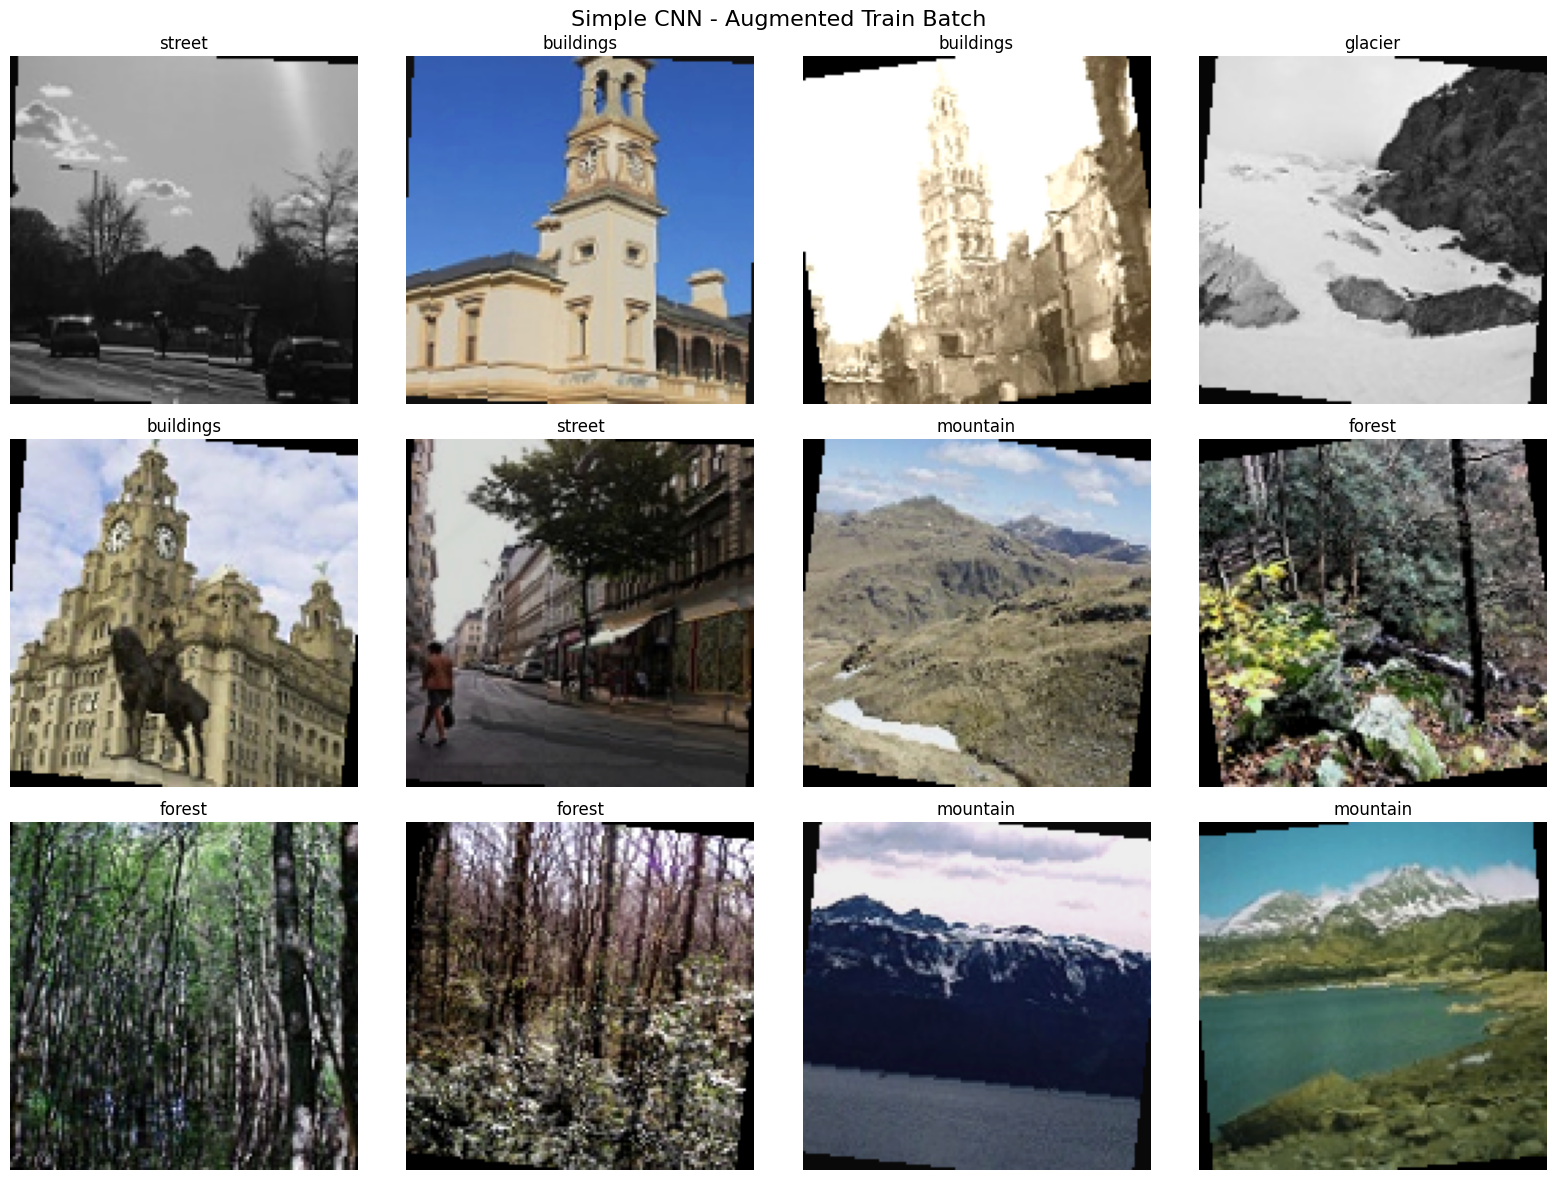

In [ ]:
def denormalize_tensor(image_tensor: torch.Tensor, mean: List[float], std: List[float]) -> torch.Tensor:
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    image = image_tensor.cpu() * std_tensor + mean_tensor
    image = torch.clamp(image, 0, 1)
    return image


def show_batch(
    loader: DataLoader,
    mean: List[float],
    std: List[float],
    title: str,
    max_images: int = 12
) -> None:
    images, labels, paths = next(iter(loader))

    n = min(max_images, images.size(0))
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(cols * 4, rows * 4))

    for i in range(n):
        image = denormalize_tensor(images[i], mean, std)
        image_np = image.permute(1, 2, 0).numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image_np)
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_batch(simple_train_loader, DATASET_MEAN, DATASET_STD, "Simple CNN - Augmented Train Batch")

## 9. Metric, train loop và utility functions

In [ ]:
def compute_metrics_from_arrays(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    prefix: str = ""
) -> Dict[str, float]:
    accuracy = accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result = {
        "accuracy": float(accuracy),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
    }

    if prefix:
        result = {f"{prefix}_{k}": v for k, v in result.items()}

    return result


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    epoch: Optional[int] = None,
    num_epochs: Optional[int] = None
) -> Dict[str, float]:
    model.train()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    desc = "Train"
    if epoch is not None and num_epochs is not None:
        desc = f"Train Epoch {epoch}/{num_epochs}"

    progress_bar = tqdm(
        loader,
        desc=desc,
        leave=False
    )

    for images, labels, _paths in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

        current_loss = running_loss / max(1, len(all_targets))
        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}"
        )

    epoch_loss = running_loss / len(loader.dataset)

    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)

    metrics = compute_metrics_from_arrays(y_true, y_pred, prefix="train")
    metrics["train_loss"] = float(epoch_loss)

    return metrics


@torch.no_grad()
def evaluate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    prefix: str = "val",
    epoch: Optional[int] = None,
    num_epochs: Optional[int] = None
) -> Dict[str, float]:
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_preds = []

    desc = prefix
    if epoch is not None and num_epochs is not None:
        desc = f"{prefix.capitalize()} Epoch {epoch}/{num_epochs}"

    progress_bar = tqdm(
        loader,
        desc=desc,
        leave=False
    )

    for images, labels, _paths in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

        current_loss = running_loss / max(1, len(all_targets))
        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}"
        )

    epoch_loss = running_loss / len(loader.dataset)

    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)

    metrics = compute_metrics_from_arrays(y_true, y_pred, prefix=prefix)
    metrics[f"{prefix}_loss"] = float(epoch_loss)

    return metrics


def get_current_lr(optimizer: optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def save_json(data: Dict[str, Any], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: Optional[optim.Optimizer],
    epoch: int,
    best_metric: float,
    model_name: str,
    extra_config: Optional[Dict[str, Any]] = None
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_name": model_name,
        "epoch": epoch,
        "best_metric": best_metric,
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class,
        "class_names": class_names,
        "config": extra_config or {}
    }

    if optimizer is not None:
        checkpoint["optimizer_state_dict"] = optimizer.state_dict()

    torch.save(checkpoint, path)


def load_model_state(model: nn.Module, checkpoint_path: Path, device: torch.device) -> Dict[str, Any]:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint

In [ ]:
def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: Optional[Any],
    num_epochs: int,
    device: torch.device,
    checkpoint_path: Path,
    history_path: Path,
    model_name: str,
    patience: int = 5,
    monitor: str = "val_macro_f1",
    extra_config: Optional[Dict[str, Any]] = None
) -> pd.DataFrame:
    model = model.to(device)

    history = []
    best_metric = -np.inf
    best_epoch = -1
    patience_counter = 0

    start_time_all = time.time()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epoch=epoch,
            num_epochs=num_epochs
        )

        val_metrics = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            prefix="val",
            epoch=epoch,
            num_epochs=num_epochs
        )

        current_lr = get_current_lr(optimizer)
        epoch_time = time.time() - epoch_start

        row = {
            "epoch": epoch,
            "lr": current_lr,
            "epoch_time_sec": epoch_time,
            **train_metrics,
            **val_metrics
        }

        history.append(row)

        current_metric = row[monitor]

        if scheduler is not None:
            # Với ReduceLROnPlateau mode=max, truyền val_macro_f1.
            scheduler.step(current_metric)

        improved = current_metric > best_metric

        if improved:
            best_metric = current_metric
            best_epoch = epoch
            patience_counter = 0

            save_checkpoint(
                path=checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                best_metric=best_metric,
                model_name=model_name,
                extra_config=extra_config
            )

            status = "saved best"
        else:
            patience_counter += 1
            status = f"no improve ({patience_counter}/{patience})"

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"train_acc={row['train_accuracy']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_acc={row['val_accuracy']:.4f} | "
            f"val_f1={row['val_macro_f1']:.4f} | "
            f"lr={current_lr:.2e} | "
            f"{status}"
        )

        # Lưu history sau mỗi epoch để tránh mất log nếu Colab disconnect.
        history_df = pd.DataFrame(history)
        history_path.parent.mkdir(parents=True, exist_ok=True)
        history_df.to_csv(history_path, index=False)

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch = {best_epoch}, best {monitor} = {best_metric:.4f}")
            break

    total_time = time.time() - start_time_all
    print(f"Finished {model_name}. Best epoch = {best_epoch}, best {monitor} = {best_metric:.4f}")
    print(f"Total training time: {total_time / 60:.2f} minutes")

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    return history_df

## 10. Prediction function

Sau khi train, notebook sẽ tạo prediction CSV cho test set.  
Notebook đánh giá sau này có thể đọc thẳng CSV này mà không cần predict lại.

In [ ]:
@torch.no_grad()
def predict_loader(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
) -> pd.DataFrame:
    model.eval()
    model = model.to(device)

    rows = []

    for images, labels, paths in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        confidences = torch.max(probs, dim=1).values

        labels_np = labels.detach().cpu().numpy()
        preds_np = preds.detach().cpu().numpy()
        confidences_np = confidences.detach().cpu().numpy()
        probs_np = probs.detach().cpu().numpy()

        for i in range(len(paths)):
            true_idx = int(labels_np[i])
            pred_idx = int(preds_np[i])

            row = {
                "relative_path": paths[i],
                "true_label_idx": true_idx,
                "pred_label_idx": pred_idx,
                "true_label": idx_to_class[true_idx],
                "pred_label": idx_to_class[pred_idx],
                "is_correct": bool(true_idx == pred_idx),
                "confidence": float(confidences_np[i])
            }

            for class_idx, class_name in idx_to_class.items():
                row[f"prob_{class_name}"] = float(probs_np[i, class_idx])

            rows.append(row)

    return pd.DataFrame(rows)


def evaluate_and_save_test_predictions(
    model: nn.Module,
    checkpoint_path: Path,
    test_loader: DataLoader,
    prediction_path: Path,
    metrics_path: Path,
    per_class_path: Path,
    device: torch.device,
    model_name: str
) -> Tuple[pd.DataFrame, Dict[str, Any], pd.DataFrame]:
    checkpoint = load_model_state(model, checkpoint_path, device)
    print(f"Loaded checkpoint for {model_name}: epoch={checkpoint['epoch']}, best_metric={checkpoint['best_metric']:.4f}")

    pred_df = predict_loader(model, test_loader, device)
    prediction_path.parent.mkdir(parents=True, exist_ok=True)
    pred_df.to_csv(prediction_path, index=False)

    y_true = pred_df["true_label_idx"].values
    y_pred = pred_df["pred_label_idx"].values

    metrics = compute_metrics_from_arrays(y_true, y_pred)
    metrics["model_name"] = model_name
    metrics["num_test_samples"] = int(len(pred_df))
    metrics["num_correct"] = int(pred_df["is_correct"].sum())
    metrics["num_wrong"] = int((~pred_df["is_correct"]).sum())
    metrics["checkpoint_path"] = str(checkpoint_path)
    metrics["prediction_path"] = str(prediction_path)

    save_json(metrics, metrics_path)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    per_class_df = pd.DataFrame(report_dict).transpose()
    per_class_path.parent.mkdir(parents=True, exist_ok=True)
    per_class_df.to_csv(per_class_path)

    print(f"\nTest metrics for {model_name}:")
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    return pred_df, metrics, per_class_df

# 11. Model 1 - Simple CNN

Simple CNN đóng vai trò là baseline deep learning tự xây.

Khác với HOG hoặc Color Histogram, CNN học trực tiếp bộ lọc convolution từ ảnh gốc.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 6, dropout: float = 0.4):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Giảm feature map về 1x1 để classifier gọn hơn.
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


simple_cnn = SimpleCNN(num_classes=NUM_CLASSES, dropout=0.4)
simple_cnn = simple_cnn.to(DEVICE)

num_params = sum(p.numel() for p in simple_cnn.parameters())
num_trainable_params = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)

print(simple_cnn)
print(f"Total params: {num_params:,}")
print(f"Trainable params: {num_trainable_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1

In [ ]:
!pip install -q torchinfo

In [ ]:
from torchinfo import summary

summary(
    simple_cnn,
    input_size=(1, 3, IMAGE_SIZE_SIMPLE, IMAGE_SIZE_SIMPLE),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    depth=4,
    device=str(DEVICE)
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SimpleCNN                                [1, 3, 128, 128]          [1, 6]                    --                        True
├─Sequential: 1-1                        [1, 3, 128, 128]          [1, 256, 1, 1]            --                        True
│    └─Conv2d: 2-1                       [1, 3, 128, 128]          [1, 32, 128, 128]         864                       True
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         [1, 32, 128, 128]         64                        True
│    └─ReLU: 2-3                         [1, 32, 128, 128]         [1, 32, 128, 128]         --                        --
│    └─MaxPool2d: 2-4                    [1, 32, 128, 128]         [1, 32, 64, 64]           --                        --
│    └─Conv2d: 2-5                       [1, 32, 64, 64]           [1, 64, 64, 64]           18,432                    True
│    └─

In [ ]:
# =========================
# Train Simple CNN
# =========================

set_seed(SEED)

simple_cnn = SimpleCNN(num_classes=NUM_CLASSES, dropout=0.4).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    simple_cnn.parameters(),
    lr=LR_SIMPLE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

simple_checkpoint_path = MODEL_DIR / "simple_cnn_best.pth"
simple_history_path = METRIC_DIR / "cs231_simple_cnn_history.csv"

simple_history = fit_model(
    model=simple_cnn,
    train_loader=simple_train_loader,
    val_loader=simple_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=EPOCHS_SIMPLE_CNN,
    device=DEVICE,
    checkpoint_path=simple_checkpoint_path,
    history_path=simple_history_path,
    model_name="simple_cnn",
    patience=PATIENCE_SIMPLE,
    monitor="val_macro_f1",
    extra_config={
        "image_size": IMAGE_SIZE_SIMPLE,
        "batch_size": BATCH_SIZE_SIMPLE,
        "epochs": EPOCHS_SIMPLE_CNN,
        "lr": LR_SIMPLE,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "normalize_mean": DATASET_MEAN,
        "normalize_std": DATASET_STD
    }
)

display(simple_history.tail())

[simple_cnn] Epoch 01/30 | train_loss=1.0593 | train_acc=0.5757 | val_loss=0.9277 | val_acc=0.6740 | val_f1=0.6719 | lr=1.00e-03 | saved best


[simple_cnn] Epoch 02/30 | train_loss=0.8026 | train_acc=0.6931 | val_loss=0.7346 | val_acc=0.7375 | val_f1=0.7344 | lr=1.00e-03 | saved best


[simple_cnn] Epoch 03/30 | train_loss=0.7163 | train_acc=0.7346 | val_loss=0.6467 | val_acc=0.7618 | val_f1=0.7594 | lr=1.00e-03 | saved best


[simple_cnn] Epoch 04/30 | train_loss=0.6532 | train_acc=0.7595 | val_loss=1.0618 | val_acc=0.5845 | val_f1=0.5627 | lr=1.00e-03 | no improve (1/6)


[simple_cnn] Epoch 05/30 | train_loss=0.6212 | train_acc=0.7732 | val_loss=0.5776 | val_acc=0.7889 | val_f1=0.7911 | lr=1.00e-03 | saved best


...

[simple_cnn] Epoch 27/30 | train_loss=0.3353 | train_acc=0.8805 | val_loss=0.3176 | val_acc=0.8891 | val_f1=0.8903 | lr=2.50e-04 | no improve (1/6)


[simple_cnn] Epoch 28/30 | train_loss=0.3399 | train_acc=0.8771 | val_loss=0.3176 | val_acc=0.8980 | val_f1=0.8989 | lr=2.50e-04 | saved best


[simple_cnn] Epoch 29/30 | train_loss=0.3295 | train_acc=0.8820 | val_loss=0.3592 | val_acc=0.8798 | val_f1=0.8796 | lr=2.50e-04 | no improve (1/6)


[simple_cnn] Epoch 30/30 | train_loss=0.3314 | train_acc=0.8811 | val_loss=0.3291 | val_acc=0.8919 | val_f1=0.8932 | lr=2.50e-04 | no improve (2/6)
Finished simple_cnn. Best epoch = 28, best val_macro_f1 = 0.8989
Total training time: 22.59 minutes


,epoch,lr,epoch_time_sec,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,train_weighted_precision,train_weighted_recall,train_weighted_f1,train_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_precision,val_weighted_recall,val_weighted_f1,val_loss
25,26,0.00025,44.494180,0.875847,0.876764,0.877078,0.876884,0.875622,0.875847,0.875697,0.346741,0.895863,0.898238,0.896487,0.896975,0.897008,0.895863,0.896052,0.315103
26,27,0.00025,44.503050,0.880485,0.881500,0.881615,0.881529,0.880374,0.880485,0.880401,0.335324,0.889087,0.890892,0.890041,0.890321,0.889725,0.889087,0.889257,0.317620
27,28,0.00025,44.284575,0.877096,0.878052,0.878202,0.878095,0.876933,0.877096,0.876982,0.339925,0.898003,0.900936,0.898866,0.898917,0.899690,0.898003,0.897849,0.317603
28,29,0.00025,45.072216,0.882001,0.882837,0.883230,0.882973,0.881740,0.882001,0.881808,0.329503,0.879815,0.889889,0.878897,0.879624,0.887634,0.879815,0.879091,0.359189
29,30,0.00025,44.816670,0.881110,0.882077,0.882101,0.881998,0.881062,0.881110,0.880992,0.331421,0.891940,0.894311,0.893202,0.893221,0.893694,0.891940,0.892309,0.329097


## 12. Test prediction cho Simple CNN

In [ ]:
simple_cnn_for_test = SimpleCNN(num_classes=NUM_CLASSES, dropout=0.4).to(DEVICE)

simple_pred_df, simple_test_metrics, simple_per_class_df = evaluate_and_save_test_predictions(
    model=simple_cnn_for_test,
    checkpoint_path=simple_checkpoint_path,
    test_loader=simple_test_loader,
    prediction_path=PRED_DIR / "cs231_simple_cnn_test_predictions.csv",
    metrics_path=METRIC_DIR / "cs231_simple_cnn_test_metrics.json",
    per_class_path=METRIC_DIR / "cs231_simple_cnn_per_class_metrics.csv",
    device=DEVICE,
    model_name="simple_cnn"
)

display(simple_pred_df.head())
display(simple_per_class_df)

Loaded checkpoint for simple_cnn: epoch=28, best_metric=0.8989

Test metrics for simple_cnn:
accuracy: 0.8847
macro_precision: 0.8888
macro_recall: 0.8841
macro_f1: 0.8850
weighted_precision: 0.8868
weighted_recall: 0.8847
weighted_f1: 0.8843
model_name: simple_cnn
num_test_samples: 3000
num_correct: 2654
num_wrong: 346
checkpoint_path: /content/intel_image_project/models/cs231/simple_cnn_best.pth
prediction_path: /content/intel_image_project/outputs/predictions/cs231_simple_cnn_test_predictions.csv


,relative_path,true_label_idx,pred_label_idx,true_label,pred_label,is_correct,confidence,prob_buildings,prob_forest,prob_glacier,prob_mountain,prob_sea,prob_street
0,seg_test/buildings/20057.jpg,0,0,buildings,buildings,True,0.996800,0.996800,3.025240e-05,0.000494,1.991752e-06,0.001943,0.000731
1,seg_test/buildings/20060.jpg,0,0,buildings,buildings,True,0.890449,0.890449,4.905268e-06,0.000254,7.079775e-09,0.000050,0.109242
2,seg_test/buildings/20061.jpg,0,0,buildings,buildings,True,0.985828,0.985828,2.510338e-07,0.000086,1.160089e-06,0.000178,0.013907
3,seg_test/buildings/20064.jpg,0,0,buildings,buildings,True,0.904701,0.904701,2.552986e-05,0.000475,1.660441e-05,0.003796,0.090986
4,seg_test/buildings/20073.jpg,0,4,buildings,sea,False,0.489176,0.235847,9.735666e-04,0.104964,1.492872e-01,0.489176,0.019752


,precision,recall,f1-score,support
buildings,0.899743,0.800915,0.847458,437.000000
forest,0.987013,0.962025,0.974359,474.000000
glacier,0.838765,0.884268,0.860915,553.000000
mountain,0.884454,0.801905,0.841159,525.000000
sea,0.890566,0.925490,0.907692,510.000000
street,0.832143,0.930140,0.878417,501.000000
accuracy,0.884667,0.884667,0.884667,0.884667
macro avg,0.888781,0.884124,0.885000,3000.000000
weighted avg,0.886766,0.884667,0.884297,3000.000000


# 13. Model 2 - ResNet18 Transfer Learning

ResNet18 được dùng như mô hình transfer learning.

Quy trình gồm 2 giai đoạn:

1. **Feature extraction**: freeze backbone, chỉ train fully connected layer cuối.
2. **Fine-tuning**: mở khóa `layer4` và `fc` để model thích nghi tốt hơn với dataset.

In [ ]:
def create_resnet18(num_classes: int = 6, pretrained: bool = True) -> nn.Module:
    """
    Tạo ResNet18 tương thích nhiều phiên bản torchvision.
    """
    if pretrained:
        try:
            weights = models.ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
        except Exception:
            model = models.resnet18(pretrained=True)
    else:
        try:
            model = models.resnet18(weights=None)
        except Exception:
            model = models.resnet18(pretrained=False)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model


def freeze_all_backbone(model: nn.Module) -> nn.Module:
    for param in model.parameters():
        param.requires_grad = False

    # Chỉ train fc cuối
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


def unfreeze_layer4_and_fc(model: nn.Module) -> nn.Module:
    # Đóng băng trước
    for param in model.parameters():
        param.requires_grad = False

    # Mở layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Mở fc
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


def count_parameters(model: nn.Module) -> Tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

## 14. Giai đoạn 1 - ResNet18 Feature Extraction

Ở giai đoạn này, backbone pretrained được freeze.  
Chỉ classifier cuối được train lại cho 6 lớp của dataset.

In [ ]:
set_seed(SEED)

resnet18_head = create_resnet18(num_classes=NUM_CLASSES, pretrained=True)
resnet18_head = freeze_all_backbone(resnet18_head)
resnet18_head = resnet18_head.to(DEVICE)

total_params, trainable_params = count_parameters(resnet18_head)

print(resnet18_head)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet18_head.parameters()),
    lr=LR_RESNET_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

resnet_head_checkpoint_path = MODEL_DIR / "resnet18_feature_extractor_best.pth"
resnet_head_history_path = METRIC_DIR / "cs231_resnet18_feature_extractor_history.csv"

resnet_head_history = fit_model(
    model=resnet18_head,
    train_loader=transfer_train_loader,
    val_loader=transfer_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=EPOCHS_RESNET_HEAD,
    device=DEVICE,
    checkpoint_path=resnet_head_checkpoint_path,
    history_path=resnet_head_history_path,
    model_name="resnet18_feature_extractor",
    patience=PATIENCE_TRANSFER,
    monitor="val_macro_f1",
    extra_config={
        "image_size": IMAGE_SIZE_TRANSFER,
        "batch_size": BATCH_SIZE_TRANSFER,
        "epochs": EPOCHS_RESNET_HEAD,
        "lr": LR_RESNET_HEAD,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "pretrained": True,
        "trainable_layers": "fc_only",
        "normalize_mean": IMAGENET_MEAN,
        "normalize_std": IMAGENET_STD
    }
)

display(resnet_head_history.tail())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[resnet18_feature_extractor] Epoch 01/8 | train_loss=0.5329 | train_acc=0.8221 | val_loss=0.3301 | val_acc=0.8773 | val_f1=0.8795 | lr=1.00e-03 | saved best


[resnet18_feature_extractor] Epoch 02/8 | train_loss=0.3365 | train_acc=0.8819 | val_loss=0.2893 | val_acc=0.9001 | val_f1=0.9010 | lr=1.00e-03 | saved best


...

[resnet18_feature_extractor] Epoch 05/8 | train_loss=0.2915 | train_acc=0.8948 | val_loss=0.2731 | val_acc=0.9044 | val_f1=0.9055 | lr=1.00e-03 | saved best


[resnet18_feature_extractor] Epoch 06/8 | train_loss=0.2792 | train_acc=0.8980 | val_loss=0.2921 | val_acc=0.8966 | val_f1=0.8969 | lr=1.00e-03 | no improve (1/5)


[resnet18_feature_extractor] Epoch 07/8 | train_loss=0.2817 | train_acc=0.8968 | val_loss=0.2648 | val_acc=0.9037 | val_f1=0.9050 | lr=1.00e-03 | no improve (2/5)


[resnet18_feature_extractor] Epoch 08/8 | train_loss=0.2720 | train_acc=0.8967 | val_loss=0.2764 | val_acc=0.9009 | val_f1=0.9016 | lr=1.00e-03 | no improve (3/5)
Finished resnet18_feature_extractor. Best epoch = 5, best val_macro_f1 = 0.9055
Total training time: 14.83 minutes


,epoch,lr,epoch_time_sec,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,train_weighted_precision,train_weighted_recall,train_weighted_f1,train_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_precision,val_weighted_recall,val_weighted_f1,val_loss
3,4,0.001,111.221869,0.896361,0.898371,0.898164,0.898254,0.896453,0.896361,0.896394,0.288501,0.901926,0.908753,0.903215,0.903651,0.906645,0.901926,0.901855,0.278331
4,5,0.001,110.991585,0.894845,0.896842,0.896651,0.896706,0.894858,0.894845,0.894810,0.291530,0.904422,0.907471,0.907428,0.905497,0.906786,0.904422,0.903552,0.273066
5,6,0.001,111.597589,0.897966,0.899680,0.899863,0.899764,0.897821,0.897966,0.897887,0.279202,0.896576,0.903377,0.898094,0.896926,0.901117,0.896576,0.894888,0.292132
6,7,0.001,111.233068,0.896807,0.898739,0.898582,0.898640,0.896865,0.896807,0.896815,0.281717,0.903709,0.906298,0.906408,0.904988,0.905606,0.903709,0.903235,0.264832
7,8,0.001,111.205501,0.896718,0.898330,0.898561,0.898440,0.896572,0.896718,0.896639,0.271997,0.900856,0.904385,0.902856,0.901598,0.903453,0.900856,0.900106,0.276430


## 15. Giai đoạn 2 - Fine-tuning ResNet18

Ở giai đoạn này:

- Load lại checkpoint tốt nhất từ giai đoạn feature extraction.
- Mở khóa `layer4` và `fc`.
- Dùng learning rate nhỏ cho backbone và lớn hơn cho classifier.

In [ ]:
set_seed(SEED)

resnet18_finetune = create_resnet18(num_classes=NUM_CLASSES, pretrained=True)
load_model_state(resnet18_finetune, resnet_head_checkpoint_path, DEVICE)

resnet18_finetune = unfreeze_layer4_and_fc(resnet18_finetune)
resnet18_finetune = resnet18_finetune.to(DEVICE)

total_params, trainable_params = count_parameters(resnet18_finetune)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    [
        {
            "params": resnet18_finetune.layer4.parameters(),
            "lr": LR_RESNET_BACKBONE
        },
        {
            "params": resnet18_finetune.fc.parameters(),
            "lr": LR_RESNET_FC
        }
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

resnet_finetuned_checkpoint_path = MODEL_DIR / "resnet18_finetuned_best.pth"
resnet_finetuned_history_path = METRIC_DIR / "cs231_resnet18_finetuned_history.csv"

resnet_finetuned_history = fit_model(
    model=resnet18_finetune,
    train_loader=transfer_train_loader,
    val_loader=transfer_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=EPOCHS_RESNET_FINETUNE,
    device=DEVICE,
    checkpoint_path=resnet_finetuned_checkpoint_path,
    history_path=resnet_finetuned_history_path,
    model_name="resnet18_finetuned",
    patience=PATIENCE_TRANSFER,
    monitor="val_macro_f1",
    extra_config={
        "image_size": IMAGE_SIZE_TRANSFER,
        "batch_size": BATCH_SIZE_TRANSFER,
        "epochs": EPOCHS_RESNET_FINETUNE,
        "lr_backbone": LR_RESNET_BACKBONE,
        "lr_fc": LR_RESNET_FC,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "pretrained": True,
        "trainable_layers": "layer4_and_fc",
        "normalize_mean": IMAGENET_MEAN,
        "normalize_std": IMAGENET_STD,
        "initialized_from": str(resnet_head_checkpoint_path)
    }
)

display(resnet_finetuned_history.tail())

Total params: 11,179,590
Trainable params: 8,396,806


[resnet18_finetuned] Epoch 01/15 | train_loss=0.2507 | train_acc=0.9127 | val_loss=0.2309 | val_acc=0.9180 | val_f1=0.9193 | lr=1.00e-05 | saved best


[resnet18_finetuned] Epoch 02/15 | train_loss=0.2180 | train_acc=0.9193 | val_loss=0.2194 | val_acc=0.9251 | val_f1=0.9261 | lr=1.00e-05 | saved best


[resnet18_finetuned] Epoch 03/15 | train_loss=0.1894 | train_acc=0.9322 | val_loss=0.2161 | val_acc=0.9269 | val_f1=0.9279 | lr=1.00e-05 | saved best


[resnet18_finetuned] Epoch 04/15 | train_loss=0.1637 | train_acc=0.9424 | val_loss=0.2007 | val_acc=0.9294 | val_f1=0.9303 | lr=1.00e-05 | saved best


...

[resnet18_finetuned] Epoch 07/15 | train_loss=0.1245 | train_acc=0.9572 | val_loss=0.1985 | val_acc=0.9297 | val_f1=0.9309 | lr=1.00e-05 | no improve (2/5)


[resnet18_finetuned] Epoch 08/15 | train_loss=0.1130 | train_acc=0.9598 | val_loss=0.2077 | val_acc=0.9297 | val_f1=0.9308 | lr=1.00e-05 | no improve (3/5)


[resnet18_finetuned] Epoch 09/15 | train_loss=0.1023 | train_acc=0.9626 | val_loss=0.2023 | val_acc=0.9287 | val_f1=0.9299 | lr=5.00e-06 | no improve (4/5)


[resnet18_finetuned] Epoch 10/15 | train_loss=0.0993 | train_acc=0.9659 | val_loss=0.2042 | val_acc=0.9269 | val_f1=0.9279 | lr=5.00e-06 | no improve (5/5)
Early stopping at epoch 10. Best epoch = 5, best val_macro_f1 = 0.9331
Finished resnet18_finetuned. Best epoch = 5, best val_macro_f1 = 0.9331
Total training time: 18.68 minutes


,epoch,lr,epoch_time_sec,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,train_weighted_precision,train_weighted_recall,train_weighted_f1,train_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_precision,val_weighted_recall,val_weighted_f1,val_loss
5,6,0.000010,113.374671,0.950945,0.952131,0.951862,0.951923,0.951002,0.950945,0.950896,0.136999,0.926177,0.927087,0.927614,0.926955,0.926015,0.926177,0.925693,0.207748
6,7,0.000010,112.213063,0.957189,0.958173,0.957951,0.957993,0.957249,0.957189,0.957148,0.124472,0.929743,0.930849,0.931134,0.930863,0.929974,0.929743,0.929734,0.198510
7,8,0.000010,112.285242,0.959775,0.960719,0.960643,0.960644,0.959777,0.959775,0.959738,0.113034,0.929743,0.930895,0.931364,0.930753,0.930468,0.929743,0.929725,0.207728
8,9,0.000005,111.975237,0.962629,0.963385,0.963391,0.963352,0.962596,0.962629,0.962576,0.102344,0.928673,0.930583,0.929943,0.929912,0.929428,0.928673,0.928694,0.202284
9,10,0.000005,111.734654,0.965929,0.966627,0.966520,0.966530,0.965966,0.965929,0.965902,0.099349,0.926890,0.927737,0.928482,0.927881,0.927015,0.926890,0.926731,0.204164


## 16. Test prediction cho ResNet18 Fine-tuned

In [ ]:
resnet18_for_test = create_resnet18(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)

resnet_pred_df, resnet_test_metrics, resnet_per_class_df = evaluate_and_save_test_predictions(
    model=resnet18_for_test,
    checkpoint_path=resnet_finetuned_checkpoint_path,
    test_loader=transfer_test_loader,
    prediction_path=PRED_DIR / "cs231_resnet18_finetuned_test_predictions.csv",
    metrics_path=METRIC_DIR / "cs231_resnet18_finetuned_test_metrics.json",
    per_class_path=METRIC_DIR / "cs231_resnet18_finetuned_per_class_metrics.csv",
    device=DEVICE,
    model_name="resnet18_finetuned"
)

display(resnet_pred_df.head())
display(resnet_per_class_df)

Loaded checkpoint for resnet18_finetuned: epoch=5, best_metric=0.9331

Test metrics for resnet18_finetuned:
accuracy: 0.9333
macro_precision: 0.9342
macro_recall: 0.9354
macro_f1: 0.9344
weighted_precision: 0.9337
weighted_recall: 0.9333
weighted_f1: 0.9331
model_name: resnet18_finetuned
num_test_samples: 3000
num_correct: 2800
num_wrong: 200
checkpoint_path: /content/intel_image_project/models/cs231/resnet18_finetuned_best.pth
prediction_path: /content/intel_image_project/outputs/predictions/cs231_resnet18_finetuned_test_predictions.csv


,relative_path,true_label_idx,pred_label_idx,true_label,pred_label,is_correct,confidence,prob_buildings,prob_forest,prob_glacier,prob_mountain,prob_sea,prob_street
0,seg_test/buildings/20057.jpg,0,0,buildings,buildings,True,0.998226,0.998226,1.936249e-05,0.000112,0.000029,0.000979,0.000634
1,seg_test/buildings/20060.jpg,0,0,buildings,buildings,True,0.995929,0.995929,8.624671e-08,0.000001,0.000001,0.000007,0.004062
2,seg_test/buildings/20061.jpg,0,0,buildings,buildings,True,0.998637,0.998637,4.722926e-07,0.000033,0.000025,0.000021,0.001283
3,seg_test/buildings/20064.jpg,0,0,buildings,buildings,True,0.999965,0.999965,8.600161e-07,0.000007,0.000005,0.000002,0.000020
4,seg_test/buildings/20073.jpg,0,0,buildings,buildings,True,0.998704,0.998704,4.445110e-07,0.000168,0.000231,0.000866,0.000031


,precision,recall,f1-score,support
buildings,0.911504,0.942792,0.926884,437.000000
forest,0.989474,0.991561,0.990516,474.000000
glacier,0.927734,0.858951,0.892019,553.000000
mountain,0.878899,0.912381,0.895327,525.000000
sea,0.947070,0.982353,0.964389,510.000000
street,0.950719,0.924152,0.937247,501.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.934233,0.935365,0.934397,3000.000000
weighted avg,0.933704,0.933333,0.933095,3000.000000


## 17. Tổng hợp nhanh kết quả huấn luyện

Notebook evaluation sau này sẽ phân tích chi tiết hơn.  
Ở đây chỉ tổng hợp nhanh để biết các file đã train xong.

In [ ]:
def load_json_if_exists(path: Path) -> Dict[str, Any]:
    if not path.exists():
        return {}

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


summary_rows = []

simple_metrics_loaded = load_json_if_exists(METRIC_DIR / "cs231_simple_cnn_test_metrics.json")
resnet_metrics_loaded = load_json_if_exists(METRIC_DIR / "cs231_resnet18_finetuned_test_metrics.json")

if simple_metrics_loaded:
    summary_rows.append({
        "model": "Simple CNN",
        "test_accuracy": simple_metrics_loaded.get("accuracy"),
        "test_macro_f1": simple_metrics_loaded.get("macro_f1"),
        "checkpoint": str(simple_checkpoint_path),
        "prediction": str(PRED_DIR / "cs231_simple_cnn_test_predictions.csv")
    })

if resnet_metrics_loaded:
    summary_rows.append({
        "model": "ResNet18 Fine-tuned",
        "test_accuracy": resnet_metrics_loaded.get("accuracy"),
        "test_macro_f1": resnet_metrics_loaded.get("macro_f1"),
        "checkpoint": str(resnet_finetuned_checkpoint_path),
        "prediction": str(PRED_DIR / "cs231_resnet18_finetuned_test_predictions.csv")
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = METRIC_DIR / "cs231_training_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print("Saved summary to:", summary_path)

,model,test_accuracy,test_macro_f1,checkpoint,prediction
0,Simple CNN,0.884667,0.885000,/content/intel_image_project/models/cs231/simp...,/content/intel_image_project/outputs/predictio...
1,ResNet18 Fine-tuned,0.933333,0.934397,/content/intel_image_project/models/cs231/resn...,/content/intel_image_project/outputs/predictio...


Saved summary to: /content/intel_image_project/outputs/metrics/cs231_training_summary.csv


In [ ]:
if IN_COLAB:
    print("Đang copy kết quả về Google Drive...")

    !rsync -ah --info=progress2 \
    "/content/intel_image_project/models/" \
    "/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/"

    !rsync -ah --info=progress2 \
    "/content/intel_image_project/outputs/" \
    "/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/"

    print("Đã lưu models và outputs về Drive.")

Đang copy kết quả về Google Drive...
        161.92M 100%  149.74MB/s    0:00:01 (xfr#3, to-chk=0/5)
          1.21M 100%    6.87MB/s    0:00:00 (xfr#10, to-chk=0/15)
Đã lưu models và outputs về Drive.


# 18. Checklist sau khi chạy notebook

Sau khi chạy xong, bạn cần kiểm tra các file sau:

```text
models/cs231/simple_cnn_best.pth
models/cs231/resnet18_feature_extractor_best.pth
models/cs231/resnet18_finetuned_best.pth

outputs/metrics/cs231_simple_cnn_history.csv
outputs/metrics/cs231_simple_cnn_test_metrics.json
outputs/metrics/cs231_simple_cnn_per_class_metrics.csv

outputs/metrics/cs231_resnet18_feature_extractor_history.csv
outputs/metrics/cs231_resnet18_finetuned_history.csv
outputs/metrics/cs231_resnet18_finetuned_test_metrics.json
outputs/metrics/cs231_resnet18_finetuned_per_class_metrics.csv

outputs/predictions/cs231_simple_cnn_test_predictions.csv
outputs/predictions/cs231_resnet18_finetuned_test_predictions.csv
```

